## Load the Model
Load 8 bit Quantized Model


In [189]:
from tensorflow.keras.models import load_model
import os
from google.colab import drive

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the path where the model was saved in Google Drive
model_save_dir = '/content/drive/My Drive/LeNet-5'
model_load_path = os.path.join(model_save_dir, 'Models/lenet5_mnist_model_q07.keras')

# Load the saved model
model = load_model(model_load_path)

# Print the summary of the loaded model to verify
model.summary()

print(f"LeNet-5 model loaded successfully from '{model_load_path}'.")

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,280 (520.63 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 88,854 (347.09 KB)

LeNet-5 model loaded successfully from '/content/drive/My Drive/LeNet-5/Models/lenet5_mnist_model_q07.keras'.


## Load MNIST Test Dataset

### Subtask:
Load the MNIST test dataset (images and labels) to be used for evaluating the accuracy of the original and quantized models.


**Reasoning**:
The subtask requires loading the MNIST test dataset, normalizing the image pixel values, and reshaping them to include a channel dimension, which is standard preprocessing for convolutional neural networks like LeNet-5. I will also one-hot encode the labels.



In [190]:
import tensorflow as tf
import numpy as np

# 1. Load the MNIST test dataset
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Original x_test shape: {x_test.shape}")
print(f"Original y_test shape: {y_test.shape}")

# 2. Preprocess the test images
# Normalize pixel values to the range [0, 1]
x_test = x_test.astype('float32') / 255.0

# Reshape images to add a channel dimension (for grayscale, it's 1 channel)
# LeNet-5 expects input shape (batch_size, height, width, channels)
x_test = np.expand_dims(x_test, -1)

# One-hot encode the labels
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"Processed x_test shape: {x_test.shape}")
print(f"Processed y_test shape: {y_test.shape}")
print("MNIST test dataset loaded and preprocessed successfully.")

Original x_test shape: (10000, 28, 28)
Original y_test shape: (10000,)
Processed x_test shape: (10000, 28, 28, 1)
Processed y_test shape: (10000, 10)
MNIST test dataset loaded and preprocessed successfully.


# Helper Function: Create Extractor Models
Creates three models for a given target layer:
    
1. Input Extractor Model: All layers before the target layer.
2. Target Layer Model: The target layer itself.
3. Remaining Model: All layers after the target layer.

    Args:
      
      original_model (tf.keras.Model): The complete original model.
      
      target_layer_name (str): The name of the layer to extract.


    Returns:

      tuple: (input_extractor_model, target_layer_model, remaining_model)

In [191]:
import tensorflow as tf

def create_feature_extractor_models(original_model, target_layer_name):
    """
    Creates three models for a given target layer:
    1. Input Extractor Model: All layers before the target layer.
    2. Target Layer Model: The target layer itself.
    3. Remaining Model: All layers after the target layer.

    Args:
        original_model (tf.keras.Model): The complete original model.
        target_layer_name (str): The name of the layer to extract.

    Returns:
        tuple: (input_extractor_model, target_layer_model, remaining_model)
    """
    # Find the target layer and its index
    target_layer = None
    target_layer_index = -1
    for i, layer in enumerate(original_model.layers):
        if layer.name == target_layer_name:
            target_layer = layer
            target_layer_index = i
    if target_layer is None:
        raise ValueError(f"Target layer '{target_layer_name}' not found in the model.")

    # 1. Create Input Extractor Model
    # This model will output the input to our target layer
    if target_layer_index == 0:
        # If target layer is the first layer, input_extractor_model is not applicable
        input_extractor_model = None
        input_to_target_layer_output = original_model.layers[0].input
    else:
        input_to_target_layer = original_model.layers[target_layer_index - 1].output
        # Ensure the model is built before accessing original_model.inputs
        if not original_model.built:
            original_model.build(input_shape=(None, 28, 28, 1)) # Assuming LeNet-5 input shape
        input_extractor_model = tf.keras.Model(inputs=original_model.inputs, outputs=input_to_target_layer,name = f"{target_layer_name}_input_extractor_model")
        input_to_target_layer_output = input_extractor_model.output

    # 2. Create Target Layer Model
    # This model takes the output of the input_extractor_model as its input
    target_layer_input_shape = target_layer.input.shape
    # Handle cases where input_shape might be (None, H, W, C) for the batch dimension
    if isinstance(target_layer_input_shape, list): # For models with multiple inputs
        # Assuming a single input for simplicity in this LeNet-5 context
        target_layer_input_shape = target_layer_input_shape[0]
    # Create a dummy input tensor with batch dimension set to None
    target_layer_input_tensor = tf.keras.Input(shape=target_layer_input_shape[1:])
    target_layer_output_tensor = target_layer(target_layer_input_tensor)
    target_layer_model = tf.keras.Model(inputs=target_layer_input_tensor, outputs=target_layer_output_tensor, name=f"{target_layer_name}_model")
    target_layer_model.set_weights(target_layer.get_weights())


    # 3. Create Remaining Model
    # This model takes the output of the target layer as its input
    if target_layer_index == len(original_model.layers) - 1:
      # If target layer is the last layer, remaining_model is not applicable
      remaining_model = None
    else:
      # Create a new input tensor for the 'remaining' part of the model
      remaining_input_tensor = tf.keras.Input(shape=target_layer.output.shape[1:])
      x = remaining_input_tensor
      for i in range(target_layer_index + 1, len(original_model.layers)):
          layer = original_model.layers[i]
          x = layer(x)
      remaining_model = tf.keras.Model(inputs=remaining_input_tensor, outputs=x, name=f"remaining_after_{target_layer_name}_model")

    return input_extractor_model, target_layer_model, remaining_model

# --- Example Usage for 'dense1' ---

target_layer_name = 'dense2'

# Assuming 'model' (the original LeNet-5) is already loaded from previous cells
# Explicitly build the model with its expected input shape
# The input shape for LeNet-5 for MNIST is (28, 28, 1)
if not model.built:
    model.build((None, 28, 28, 1)) # None for batch dimension

input_extractor_model, dense1_model, remaining_model = \
    create_feature_extractor_models(model, target_layer_name)

print(f"\n--- Models for '{target_layer_name}' ---")

if input_extractor_model:
    print("\nInput Extractor Model Summary:")
    input_extractor_model.summary()

print("\nTarget Layer Model Summary (dense1):")
dense1_model.summary()

if remaining_model:
    print("\nRemaining Model Summary:")
    remaining_model.summary()

print("\nFeature extraction models defined and instantiated for 'dense1'.")



--- Models for 'dense2' ---

Input Extractor Model Summary:


Model: "dense2_input_extractor_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,412 (130.52 KB)

 Trainable params: 33,412 (130.52 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_107 (InputLayer)    │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 850 (3.32 KB)

 Trainable params: 850 (3.32 KB)

 Non-trainable params: 0 (0.00 B)


Feature extraction models defined and instantiated for 'dense1'.


In [192]:
import numpy as np

def quantize_to_q4_n(data, n):
    """
    Quantizes data into Unsigned Q4.n format.

    Args:
        data (float or np.array): The input value(s) to quantize.
        n (int): The number of fractional bits.

    Returns:
        np.array: The integer representation of the quantized value,
                  with the same shape as the input 'data'.
    """
    # Ensure data is a NumPy array for element-wise operations
    data_array = np.asarray(data)

    # Total bits = 4 (integer) + n (fractional)
    total_bits = 4 + n

    # 1. Scaling Factor
    scaling_factor = 2**n

    # 2. Scale and Round
    quantized = np.round(data_array * scaling_factor)

    # 3. Determine Boundaries
    # Unsigned min is 0. Max is (2^bits) - 1.
    lower_bound = 0
    upper_bound = (2**total_bits) - 1

    # 4. Clip (Saturation)
    quantized_clipped = np.clip(quantized, lower_bound, upper_bound)
    # 5. Scale Back
    # Divide by the scaling factor to convert back to floating-point Q0.15 quantized value
    scale_back = quantized_clipped / scaling_factor

    # Return the clipped integer representation, ensuring integer type
    return scale_back

# --- Example Usage demonstrating shape preservation ---
max_n_bits = 12
# Test with a 1D array
test_vals_1d = [12.18567926889, 9.233, 7.25]
print("--- Testing with 1D array ---")
data_to_quantize = np.array(test_vals_1d)
print(f"Original shape: {data_to_quantize.shape}, Data: {data_to_quantize}")
for n_bits in range(max_n_bits): # Test n=0, 1, 2
  q_val = quantize_to_q4_n(data_to_quantize, n=n_bits)
  print(f"  for n_bit = {n_bits}, Quantized shape: {q_val.shape}, Quantized values: {q_val}")

# Test with a 2D array
test_vals_2d = np.array([[1.5, 3.2], [0.1, 15.9]])
print("\n--- Testing with 2D array ---")
data_to_quantize = test_vals_2d
print(f"Original shape: {data_to_quantize.shape}, Data: {data_to_quantize}")
for n_bits in range(max_n_bits): # Test n=0, 1, 2
  q_val = quantize_to_q4_n(data_to_quantize, n=n_bits)
  print(f"  for n_bit = {n_bits}, Quantized shape: {q_val.shape}, Quantized values: {q_val}")

# Test with a scalar
test_vals_scalar = 5.7
print("\n--- Testing with scalar ---")
data_to_quantize = test_vals_scalar
print(f"Original shape: {np.asarray(data_to_quantize).shape}, Data: {data_to_quantize}")
for n_bits in range(max_n_bits): # Test n=0, 1, 2
  q_val = quantize_to_q4_n(data_to_quantize, n=n_bits)
  print(f"  for n_bit = {n_bits}, Quantized shape: {np.asarray(q_val).shape}, Quantized values: {q_val}")

--- Testing with 1D array ---
Original shape: (3,), Data: [12.18567927  9.233       7.25      ]
  for n_bit = 0, Quantized shape: (3,), Quantized values: [12.  9.  7.]
  for n_bit = 1, Quantized shape: (3,), Quantized values: [12.  9.  7.]
  for n_bit = 2, Quantized shape: (3,), Quantized values: [12.25  9.25  7.25]
  for n_bit = 3, Quantized shape: (3,), Quantized values: [12.125  9.25   7.25 ]
  for n_bit = 4, Quantized shape: (3,), Quantized values: [12.1875  9.25    7.25  ]
  for n_bit = 5, Quantized shape: (3,), Quantized values: [12.1875   9.21875  7.25   ]
  for n_bit = 6, Quantized shape: (3,), Quantized values: [12.1875    9.234375  7.25    ]
  for n_bit = 7, Quantized shape: (3,), Quantized values: [12.1875    9.234375  7.25    ]
  for n_bit = 8, Quantized shape: (3,), Quantized values: [12.1875    9.234375  7.25    ]
  for n_bit = 9, Quantized shape: (3,), Quantized values: [12.18554688  9.23242188  7.25      ]
  for n_bit = 10, Quantized shape: (3,), Quantized values: [12.1

In [193]:
import numpy as np

def quantize_q07(value):
    """Quantizes a floating-point number (or array) to Q0.7 fixed-point representation.
    (1 sign bit, 0 integer bits, 7 fractional bits, total 8 bits)
    Representable range: [-1.0, ~0.992]
    """
    # Scaling factor for Q0.7 (2^7)
    scale_factor = 2**7

    # Ensure value is a NumPy array for element-wise operations
    value_array = np.asarray(value)

    # Multiply by scaling factor and round to the nearest integer
    scaled_value = np.round(value_array * scale_factor)

    # Clamp the integer result to the valid range for a signed 8-bit integer (-128 to 127)
    clamped_value = np.clip(scaled_value, -128, 127)

    # Apply the signed Q0.7 conversion element-wise using np.where
    # Negative clamped_value are mapped to their unsigned 8-bit two's complement representation
    quantized_value = np.where(clamped_value < 0,
                               np.uint8(clamped_value + 256),
                               np.uint8(clamped_value))

    return quantized_value

sample_values_q07 = [0.5,-0.5, 0.25,-0.25, 0.99, -0.99, 1.2, -1.2, 0.001, -0.001]
for value in sample_values_q07:
  q_value = quantize_q07(value)
  print(f"value = {value} -> quanitzed uint8 value = {q_value}")

value = 0.5 -> quanitzed uint8 value = 64
value = -0.5 -> quanitzed uint8 value = 192
value = 0.25 -> quanitzed uint8 value = 32
value = -0.25 -> quanitzed uint8 value = 224
value = 0.99 -> quanitzed uint8 value = 127
value = -0.99 -> quanitzed uint8 value = 129
value = 1.2 -> quanitzed uint8 value = 127
value = -1.2 -> quanitzed uint8 value = 128
value = 0.001 -> quanitzed uint8 value = 0
value = -0.001 -> quanitzed uint8 value = 0


In [194]:
import numpy as np
import os
from google.colab import drive

def save_quantized_array_to_files(flat_array, file_name, n_bits, output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights'):
    """
    Saves a numpy array (assumed to contain scaled floating-point values representing
    fixed-point numbers) to a CSV file and a .mem file (in hexadecimal integer format).

    Args:
        array_input (np.ndarray,list): The numpy array of scaled floating-point values.
                                 This array will be flattened before saving.
        file_name (str): The base name for the output files (e.g., "feature_map_1").
        n_bits (int): The number of fractional bits (n) used in the Q4.n format. This is used for scaling to integer representation.
        output_base_dir (str): The base directory in Google Drive to save the files.
                               Defaults to '/content/drive/My Drive/LeNet-5/Quantized_Weights'.
    """
    # Mount Google Drive if not already mounted
    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')

    # Ensure the output directory exists
    os.makedirs(output_base_dir, exist_ok=True)

    # Flatten the array to 1D
    flat_array = np.array(flat_array)
    # Scaling Factor
    scaling_factor = 2**n_bits

    # --- Save to CSV ---
    csv_file_path = os.path.join(output_base_dir, f"{file_name}.csv")
    np.savetxt(csv_file_path, flat_array, delimiter=",", fmt='%.8f')
    print(f"Saved CSV file to: {csv_file_path}")

    # --- Save to MEM (hexadecimal integer format) ---
    mem_file_path = os.path.join(output_base_dir, f"{file_name}.mem")

    # Convert floats back to their integer fixed-point representation.
    # Then explicitly cast to 8-bit unsigned integer type as requested for the memory file format.
    # This handles both signed (two's complement) and unsigned 8-bit values,
    # mapping signed negative values to their unsigned 8-bit representation (e.g., -128 -> 128, -1 -> 255).
    # Values outside the 8-bit unsigned range (0-255) will be clipped implicitly by np.uint8.
    fixed_point_integers_8bit = np.round(flat_array * scaling_factor).astype(np.uint8)

    # For 8-bit output, we always need 2 hexadecimal digits.
    hex_format_string = "02X"

    with open(mem_file_path, 'w') as f:
        for val in fixed_point_integers_8bit:
            f.write(f"{val:{hex_format_string}}\n")
    print(f"Saved MEM file to: {mem_file_path}")

print("Function 'save_quantized_array_to_files' defined.")

# Example usage
file_name = f"Test"
array = np.array([1.2,3.5622,2.866,0.213,1.33])
# Assuming n_bits=4 for Q4.4, resulting in values that *could* fit within 8 bits
# The output for the .mem file will now always be forced to 8-bit unsigned hex.
save_quantized_array_to_files(array, file_name, n_bits = 4)

Function 'save_quantized_array_to_files' defined.
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Test.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Test.mem


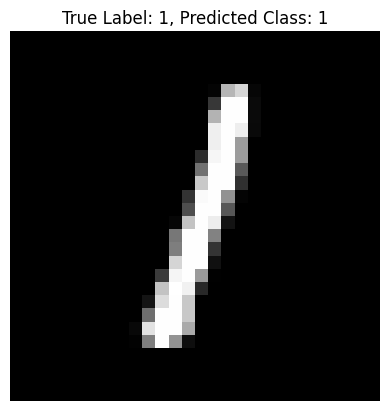

Original Image Shape: (28, 28, 1)
Image for Prediction Shape: (1, 28, 28, 1)
Prediction Probabilities: [[1.02072543e-11 9.99999881e-01 1.14223795e-08 3.95694965e-14
  3.16220800e-10 1.51365882e-11 2.62962513e-10 1.42133700e-07
  2.08789341e-09 1.78321993e-11]]
True Label: 1
Predicted Class: 1


In [195]:
import numpy as np
import matplotlib.pyplot as plt

#-------------- Quantized Model ------------------
### testing the model
conv1poo1_model, conv2_model,_ = create_feature_extractor_models(model,"conv2")
_,pool2_model,_    = create_feature_extractor_models(model,"pool2")
_,flatten_mdoel,_  = create_feature_extractor_models(model,"flatten")
_,dense1_model,_   = create_feature_extractor_models(model,"dense1")
_,dense2_model,out_model = create_feature_extractor_models(model,"dense2")

# Get a random index from the test dataset
random_index = np.random.randint(0, len(x_test))

# Get the random test image and its true label
random_image = x_test[random_index]
true_label_one_hot = y_test[random_index]
true_label = np.argmax(true_label_one_hot)

# The model expects a batch of images, so add a batch dimension
# The shape of random_image is (28, 28, 1), we need (1, 28, 28, 1)
image_for_prediction = np.expand_dims(random_image, axis=0)

# Make a prediction using the model

# Add a batch dimension to the single image
Feature_Map_1 = conv1poo1_model.predict(image_for_prediction, verbose=0)
Feature_Map_1 = quantize_to_q4_n(Feature_Map_1, n=4)

connect_FM_1  = conv2_model.predict(Feature_Map_1, verbose=0)
Feature_Map_2 = pool2_model.predict(connect_FM_1, verbose=0)
Feature_Map_2 = quantize_to_q4_n(Feature_Map_2, n=4)

connect_FM_2  = flatten_mdoel.predict(Feature_Map_2, verbose=0)
Feature_Map_3 = dense1_model.predict(connect_FM_2, verbose=0)
Feature_Map_3 = quantize_to_q4_n(Feature_Map_3, n=4)

Feature_Map_4  = dense2_model.predict(Feature_Map_3, verbose=0)
Feature_Map_4  = quantize_to_q4_n(Feature_Map_4, n=4)

predictions = out_model.predict(Feature_Map_4, verbose=0)
predicted_class = np.argmax(predictions)

# Display the image and prediction
plt.imshow(random_image.squeeze(), cmap='gray') # .squeeze() removes the channel dimension for display
plt.title(f"True Label: {true_label}, Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()

print(f"Original Image Shape: {random_image.shape}")
print(f"Image for Prediction Shape: {image_for_prediction.shape}")
print(f"Prediction Probabilities: {predictions}")
print(f"True Label: {true_label}")
print(f"Predicted Class: {predicted_class}")


# Parameter Extraction
- Extract Weights,bias from layer
- Extract input and Output features from the layer
- Flatten both of them by hand
- turn them into .csv and .mem files

In [196]:
# Image
print(f"Shape of Image: {image_for_prediction.shape}")
flatted_image = image_for_prediction.flatten()
save_quantized_array_to_files(flatted_image,f"Image", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/Image')
# Feature Map 1
print(f"Shape of Feature Map 1: {Feature_Map_1.shape}")

for i in range(Feature_Map_1.shape[3]):
    # Feature_Map [Weights = 0 , Bais = 1] [Filter Demensions]
    flatted_Feature_Map_1_parts = [] # Use a list to collect parts

    # The original code's intent for Feature_Map_1[0][:][:][0] was likely to show the first channel.
    # Feature_Map_1[0, :, :, 0] extracts the 2D data for the first channel (shape: 12x12).
    print(f"Unflat Feature Map {i} (First Channel, shape {Feature_Map_1[0, :, :, i].shape})")
    # print(Feature_Map_1[0][:][:][i]) # Print the first channel for better understanding

    # Feature Map 1 Parts
    Feature_Map_1_parts = Feature_Map_1[0][:][:][i]
    # Concatenate all collected parts into a single 1D array
    flatted_Feature_Map_1 = Feature_Map_1_parts.flatten()
    flatted_Feature_Map_1 = quantize_to_q4_n(flatted_Feature_Map_1, 4)

    save_quantized_array_to_files(flatted_Feature_Map_1,f"Feature_Map_1_Filter_{i+1}", n_bits=4,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/FM_1')

# Feature Map 2
print(f"Shape of Feature Map 2: {Feature_Map_2.shape}")

for i in range(Feature_Map_2.shape[3]):
    # Feature_Map [Weights = 0 , Bais = 1] [Filter Demensions]
    flatted_Feature_Map_2_parts = [] # Use a list to collect parts

    # The original code's intent for Feature_Map_1[0][:][:][0] was likely to show the first channel.
    # Feature_Map_1[0, :, :, 0] extracts the 2D data for the first channel (shape: 12x12).
    print(f"Unflat Feature Map {i} (First Channel, shape {Feature_Map_2[0, :, :, i].shape})")
    # print(Feature_Map_1[0][:][:][i]) # Print the first channel for better understanding

    # Feature Map 1 Parts
    Feature_Map_2_parts = Feature_Map_2[0, :, :, i]
    # Concatenate all collected parts into a single 1D array
    flatted_Feature_Map_2 = Feature_Map_2_parts.flatten()
    flatted_Feature_Map_2 = quantize_to_q4_n(flatted_Feature_Map_2, 4)

    save_quantized_array_to_files(flatted_Feature_Map_2,f"Feature_Map_2_Filter_{i+1}", n_bits=4,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/FM_2')

# Feature Map 3
print(f"Shape of Feature Map 3: {Feature_Map_3.shape}")

flatted_Feature_Map_3 = quantize_to_q4_n(Feature_Map_3, 4).flatten()
save_quantized_array_to_files(flatted_Feature_Map_3,f"Feature_Map_3", n_bits=4,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/FM_3')

# Feature Map 4
print(f"Shape of Feature Map 4: {Feature_Map_4.shape}")

flatted_Feature_Map_4 = quantize_to_q4_n(Feature_Map_4, 4).flatten()
save_quantized_array_to_files(flatted_Feature_Map_4,f"Feature_Map_3", n_bits=4,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/FM_4')

# predictions
print(f"Shape of predictions: {predictions.shape}")

flatted_predictions = quantize_to_q4_n(predictions, 4).flatten()
save_quantized_array_to_files(flatted_predictions,f"Predictions", n_bits=4,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/Predication')

Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Image/Image.mem
Shape of Feature Map 1: (1, 12, 12, 6)
Unflat Feature Map 0 (First Channel, shape (12, 12))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/FM_1/Feature_Map_1_Filter_1.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/FM_1/Feature_Map_1_Filter_1.mem
Unflat Feature Map 1 (First Channel, shape (12, 12))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/FM_1/Feature_Map_1_Filter_2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/FM_1/Feature_Map_1_Filter_2.mem
Unflat Feature Map 2 (First Channel, shape (12, 12))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/FM_1/Feature_Map_1_Filter_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/FM_1/Feature_Map_1_Filter_3

## Weights

In [197]:
# Weights/Bais conv1
conv1_weight = model.layers[0].get_weights()[0]
conv1_bias = model.layers[0].get_weights()[1]
print(f"Shape of Conv1 weight = {conv1_weight.shape}")

for i in range(conv1_weight.shape[3]):
    # The third dimension (axis 2) of conv1_weight is the input channel and has size 1.
    # So, we should access index 0, not 1.
    # For the print statement and data extraction, use index 0 for the third axis.

    print(f"Unflat Feature Map {i} (First Channel, shape {conv1_weight[:, :, 0, i].shape})")

    # Feature Map 1 Parts - Corrected to access index 0 for the input channel
    conv1_weight_parts = conv1_weight[:, :, 0, i]

    # Flatten the weight parts
    flatted_conv1_weight = conv1_weight_parts.flatten()

    # Quantize the flattened weights using quantize_q07
    # The original code was incorrectly using quantize_q07 on 'flatted_Feature_Map_2'
    # which is a feature map, not the weights being processed in this loop.
    flatted_conv1_weight = quantize_q07(flatted_conv1_weight)

    # Save the quantized conv1 weights.
    # The original code was incorrectly saving 'flatted_predictions'.
    save_quantized_array_to_files(flatted_conv1_weight, f"conv1_weights_filter_{i+1}", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/conv1')


print(f"Shape of Conv1 bais = {conv1_bias.shape}")

flatted_conv1_bias = quantize_q07(conv1_bias).flatten()
save_quantized_array_to_files(flatted_conv1_bias, f"conv1_bais", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/conv1')


Shape of Conv1 weight = (5, 5, 1, 6)
Unflat Feature Map 0 (First Channel, shape (5, 5))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv1/conv1_weights_filter_1.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv1/conv1_weights_filter_1.mem
Unflat Feature Map 1 (First Channel, shape (5, 5))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv1/conv1_weights_filter_2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv1/conv1_weights_filter_2.mem
Unflat Feature Map 2 (First Channel, shape (5, 5))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv1/conv1_weights_filter_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv1/conv1_weights_filter_3.mem
Unflat Feature Map 3 (First Channel, shape (5, 5))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv1/conv1_weights_filter_4.csv
Saved MEM file to: /content/drive/My Drive/Le

In [198]:
# Weights/Bais conv1
conv2_weight = model.layers[2].get_weights()[0]
conv2_bias = model.layers[2].get_weights()[1]
print(f"Shape of Conv2 weight = {conv2_weight.shape}")

for i in range(conv2_weight.shape[2]):
  for j in range(conv2_weight.shape[3]):
      # The third dimension (axis 2) of conv1_weight is the input channel and has size 1.
      # So, we should access index 0, not 1.
      # For the print statement and data extraction, use index 0 for the third axis.

      print(f"For Feature Map {i}:Unflat Weight {j} ({i} Channel, shape {conv2_weight[:, :, i, j].shape})")

      # Feature Map 1 Parts - Corrected to access index 0 for the input channel
      conv2_weight_parts = conv2_weight[:, :, i, j]

      # Flatten the weight parts
      flatted_conv2_weight = conv2_weight_parts.flatten()

      # Quantize the flattened weights using quantize_q07
      # The original code was incorrectly using quantize_q07 on 'flatted_Feature_Map_2'
      # which is a feature map, not the weights being processed in this loop.
      flatted_conv2_weight = quantize_q07(flatted_conv2_weight)

      # Save the quantized conv1 weights.
      # The original code was incorrectly saving 'flatted_predictions'.
      save_quantized_array_to_files(flatted_conv2_weight, f"conv2_weights_Channel{i+1}_filter_{j+1}", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/conv2')


print(f"Shape of Conv2 bais = {conv2_bias.shape}")

flatted_conv2_bias = quantize_q07(conv2_bias).flatten()
save_quantized_array_to_files(flatted_conv2_bias, f"conv2_bais", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/conv2')


Shape of Conv2 weight = (5, 5, 6, 16)
For Feature Map 0:Unflat Weight 0 (0 Channel, shape (5, 5))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv2/conv2_weights_Channel1_filter_1.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv2/conv2_weights_Channel1_filter_1.mem
For Feature Map 0:Unflat Weight 1 (0 Channel, shape (5, 5))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv2/conv2_weights_Channel1_filter_2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv2/conv2_weights_Channel1_filter_2.mem
For Feature Map 0:Unflat Weight 2 (0 Channel, shape (5, 5))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv2/conv2_weights_Channel1_filter_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/conv2/conv2_weights_Channel1_filter_3.mem
For Feature Map 0:Unflat Weight 3 (0 Channel, shape (5, 5))
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quant

In [199]:
# Weights/Bais Dense 1
dense1_weight = model.layers[5].get_weights()[0]
dense1_bias = model.layers[5].get_weights()[1]
print(f"Shape of dense1 weight = {dense1_weight.shape}")
flatted_dense1_weight = quantize_q07(dense1_weight).flatten()
save_quantized_array_to_files(flatted_dense1_weight, f"dense1_weight", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/dense1')

print(f"Shape of dense1 bais = {dense1_bias.shape}")
flatted_dense1_bias = quantize_q07(dense1_bias).flatten()
save_quantized_array_to_files(flatted_dense1_bias, f"dense1_bias", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/dense1')



Shape of dense1 weight = (256, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense1/dense1_weight.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense1/dense1_weight.mem
Shape of dense1 bais = (120,)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense1/dense1_bias.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense1/dense1_bias.mem


In [200]:
# Weights/Bais Dense 2
dense2_weight = model.layers[6].get_weights()[0]
dense2_bias = model.layers[6].get_weights()[1]
print(f"Shape of dense2 weight = {dense2_weight.shape}")
flatted_dense2_weight = quantize_q07(dense2_weight).flatten()
save_quantized_array_to_files(flatted_dense2_weight, f"dense2_weight", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/dense2')

print(f"Shape of dense2 bais = {dense2_bias.shape}")
flatted_dense2_bias = quantize_q07(dense2_bias).flatten()
save_quantized_array_to_files(flatted_dense2_bias, f"dense2_bias", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/dense2')


Shape of dense2 weight = (120, 84)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense2/dense2_weight.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense2/dense2_weight.mem
Shape of dense2 bais = (84,)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense2/dense2_bias.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense2/dense2_bias.mem


In [201]:
# Weights/Bais Dense 3
dense3_weight = model.layers[6].get_weights()[0]
dense3_bias = model.layers[6].get_weights()[1]
print(f"Shape of dense3 weight = {dense3_weight.shape}")
flatted_dense3_weight = quantize_q07(dense3_weight).flatten()
save_quantized_array_to_files(flatted_dense3_weight, f"dense3_weight", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/dense3')

print(f"Shape of dense3 bais = {dense3_bias.shape}")
flatted_dense3_bias = quantize_q07(dense3_bias).flatten()
save_quantized_array_to_files(flatted_dense3_bias, f"dense3_bias", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/dense3')



Shape of dense3 weight = (120, 84)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense3/dense3_weight.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense3/dense3_weight.mem
Shape of dense3 bais = (84,)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense3/dense3_bias.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/dense3/dense3_bias.mem
